<a href="https://colab.research.google.com/github/MirWaseer/HeartDiseasePrediction/blob/main/Heartdiseaseprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
'''
Heart Disease Prediction using Machine Learning
 Random Forest Classifier | UCI Heart Disease Dataset
 Run this on Google Colab

'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    precision_recall_curve
)

sns.set_theme(style="whitegrid", palette="Set2")
print("✅ Libraries imported successfully.")



✅ Libraries imported successfully.


In [22]:
# Load directly from UCI via URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(url, header=None, names=columns, na_values="?")

# Binarise target (0 = No Disease, 1 = Disease)
df["target"] = (df["target"] > 0).astype(int)

print(f"✅ Dataset loaded. Shape: {df.shape}")
print(df.head())





✅ Dataset loaded. Shape: (303, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


In [23]:

print("\n── Missing Values ──")
print(df.isnull().sum())

# Fill missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)


── Missing Values ──
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


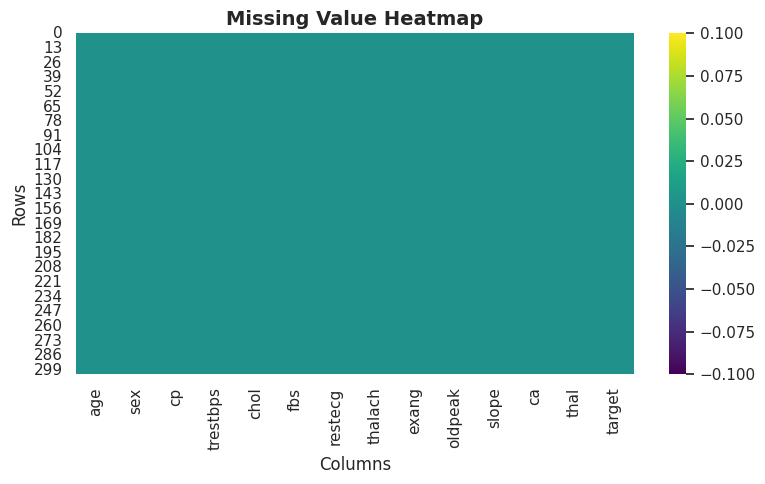

In [3]:
# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=True, cmap="viridis", ax=ax)
ax.set_title("Missing Value Heatmap", fontsize=14, fontweight="bold")
ax.set_xlabel("Columns")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.savefig("fig2_missing_values.png", dpi=150)
plt.show()


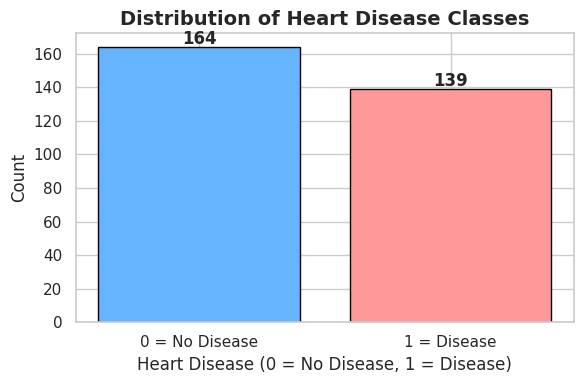

In [4]:
# ── 4. CLASS DISTRIBUTION ────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["target"].value_counts()
bars = ax.bar(["0 = No Disease", "1 = Disease"], counts.values,
              color=["#66b3ff", "#ff9999"], edgecolor="black")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha="center", fontsize=12, fontweight="bold")
ax.set_title("Distribution of Heart Disease Classes", fontsize=14, fontweight="bold")
ax.set_xlabel("Heart Disease (0 = No Disease, 1 = Disease)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("fig3_class_distribution.png", dpi=150)
plt.show()


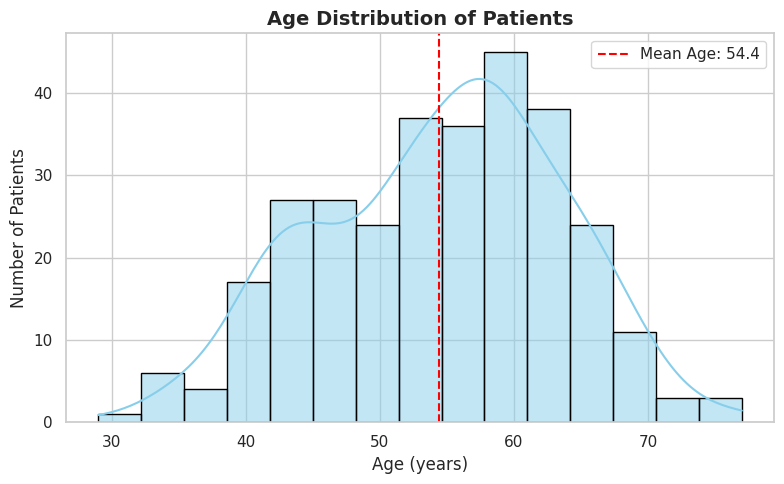

In [5]:
# ── 5. AGE DISTRIBUTION ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["age"], bins=15, kde=True, color="skyblue",
             edgecolor="black", ax=ax)
ax.set_title("Age Distribution of Patients", fontsize=14, fontweight="bold")
ax.set_xlabel("Age (years)", fontsize=12)
ax.set_ylabel("Number of Patients", fontsize=12)
ax.axvline(df["age"].mean(), color="red", linestyle="--", label=f"Mean Age: {df['age'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.savefig("fig5_age_distribution.png", dpi=150)
plt.show()


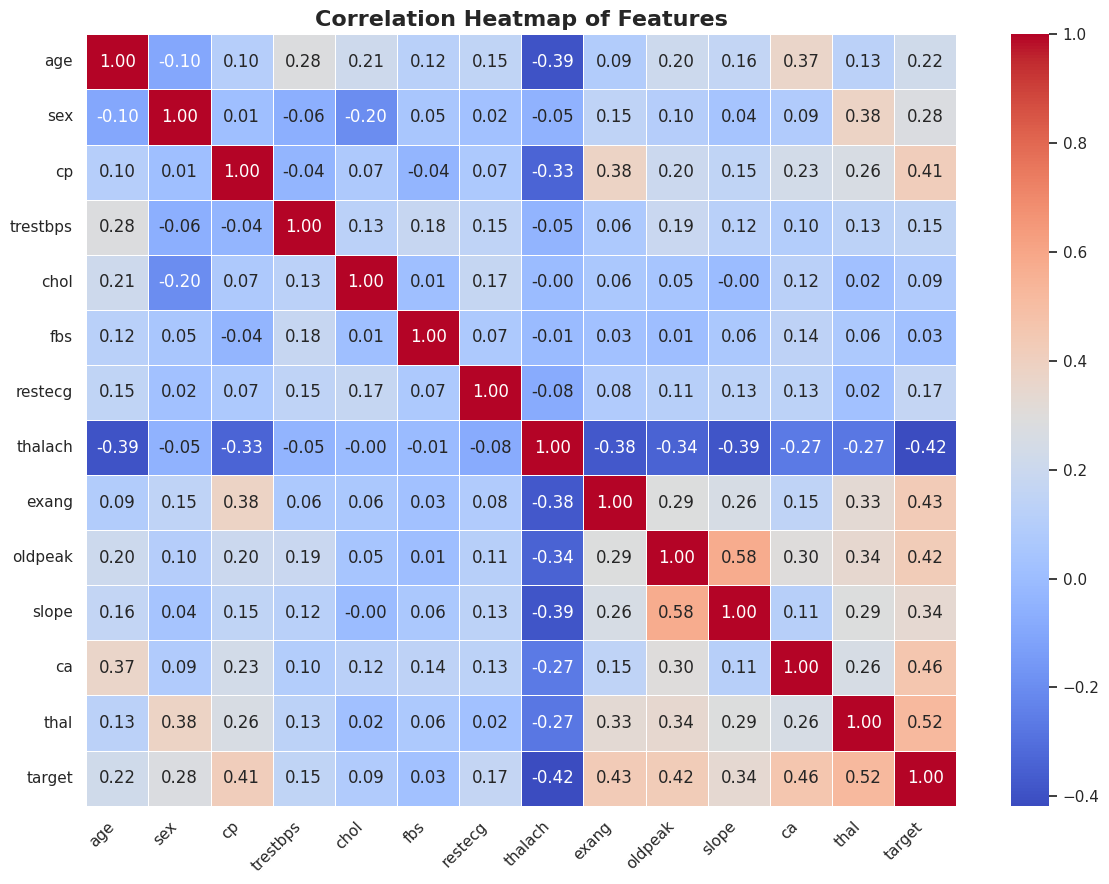

In [6]:
# ── 6. CORRELATION HEATMAP ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5,
            linecolor="white", cbar=True, cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap of Features", fontsize=16, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("fig4_correlation_heatmap.png", dpi=150)
plt.show()


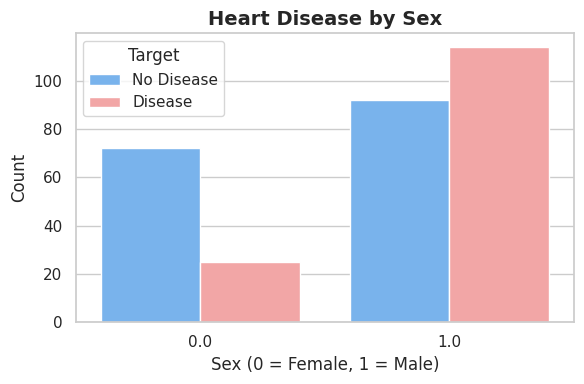

In [7]:
# ── 7.Sex vs Heart Disease ───────────────
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="sex", hue="target",
              palette=["#66b3ff", "#ff9999"], ax=ax)
ax.set_title("Heart Disease by Sex", fontsize=14, fontweight="bold")
ax.set_xlabel("Sex (0 = Female, 1 = Male)")
ax.set_ylabel("Count")
ax.legend(title="Target", labels=["No Disease", "Disease"])
plt.tight_layout()
plt.savefig("extra_sex_vs_target.png", dpi=150)
plt.show()


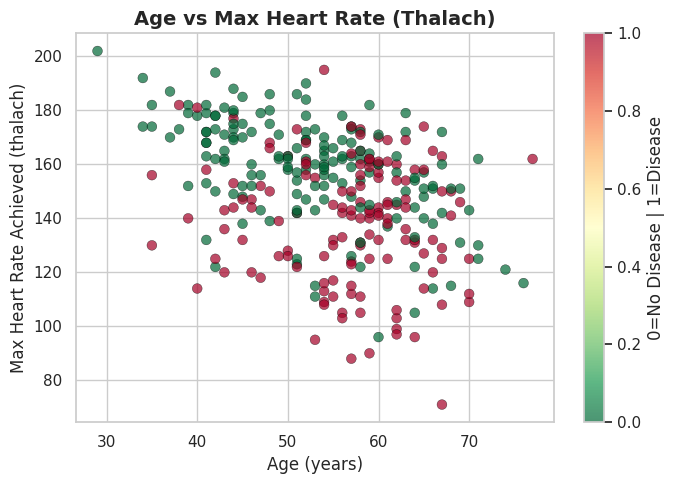

In [9]:
# ── 9. ADDITIONAL PLOT C: Age vs Max Heart Rate (thalach) ────
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(df["age"], df["thalach"],
                     c=df["target"], cmap="RdYlGn_r",
                     alpha=0.7, edgecolors="k", linewidths=0.3, s=50)
plt.colorbar(scatter, ax=ax, label="0=No Disease | 1=Disease")
ax.set_title("Age vs Max Heart Rate (Thalach)", fontsize=14, fontweight="bold")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Max Heart Rate Achieved (thalach)")
plt.tight_layout()
plt.savefig("extra_age_vs_thalach.png", dpi=150)
plt.show()


/tmp/ipykernel_602/1277797697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=feat,
/tmp/ipykernel_602/1277797697.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Disease", "Disease"])
/tmp/ipykernel_602/1277797697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=feat,
/tmp/ipykernel_602/1277797697.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Disease", "Disease"])
/tmp/ipykernel_602/1277797697.py:5: FutureWarning: 


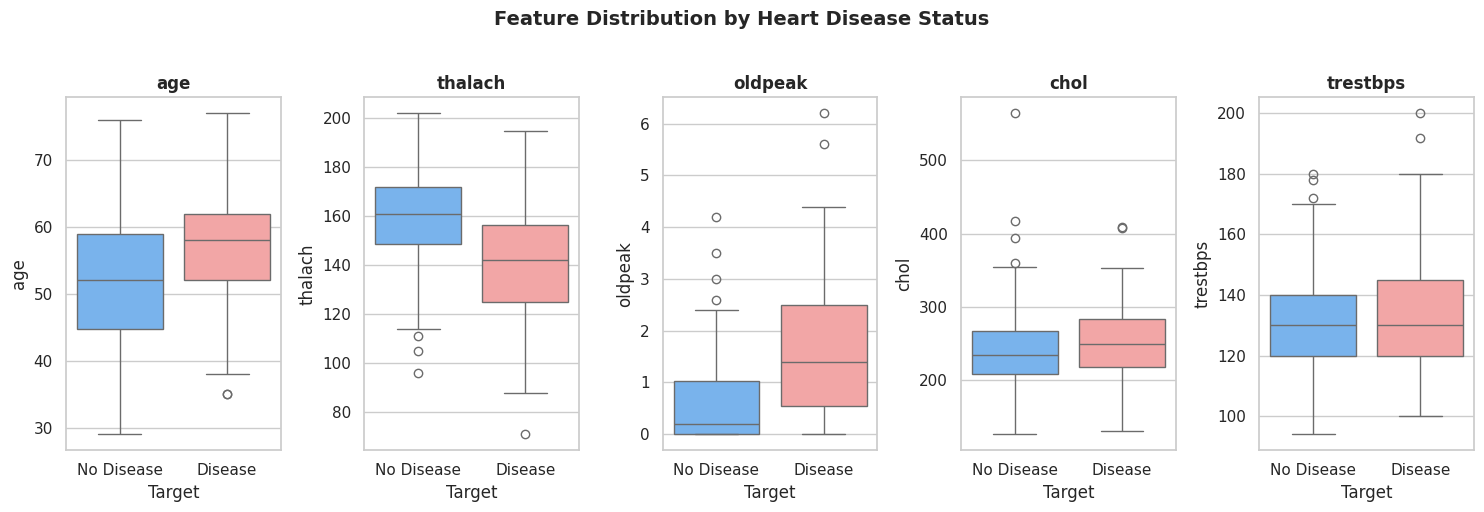

In [10]:
# ── 10. Box Plots of Key Features ─────────
key_features = ["age", "thalach", "oldpeak", "chol", "trestbps"]
fig, axes = plt.subplots(1, len(key_features), figsize=(15, 5))
for ax, feat in zip(axes, key_features):
    sns.boxplot(data=df, x="target", y=feat,
                palette=["#66b3ff", "#ff9999"], ax=ax)
    ax.set_title(feat, fontsize=12, fontweight="bold")
    ax.set_xlabel("Target")
    ax.set_xticklabels(["No Disease", "Disease"])
plt.suptitle("Feature Distribution by Heart Disease Status",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("extra_box_plots.png", dpi=150)
plt.show()


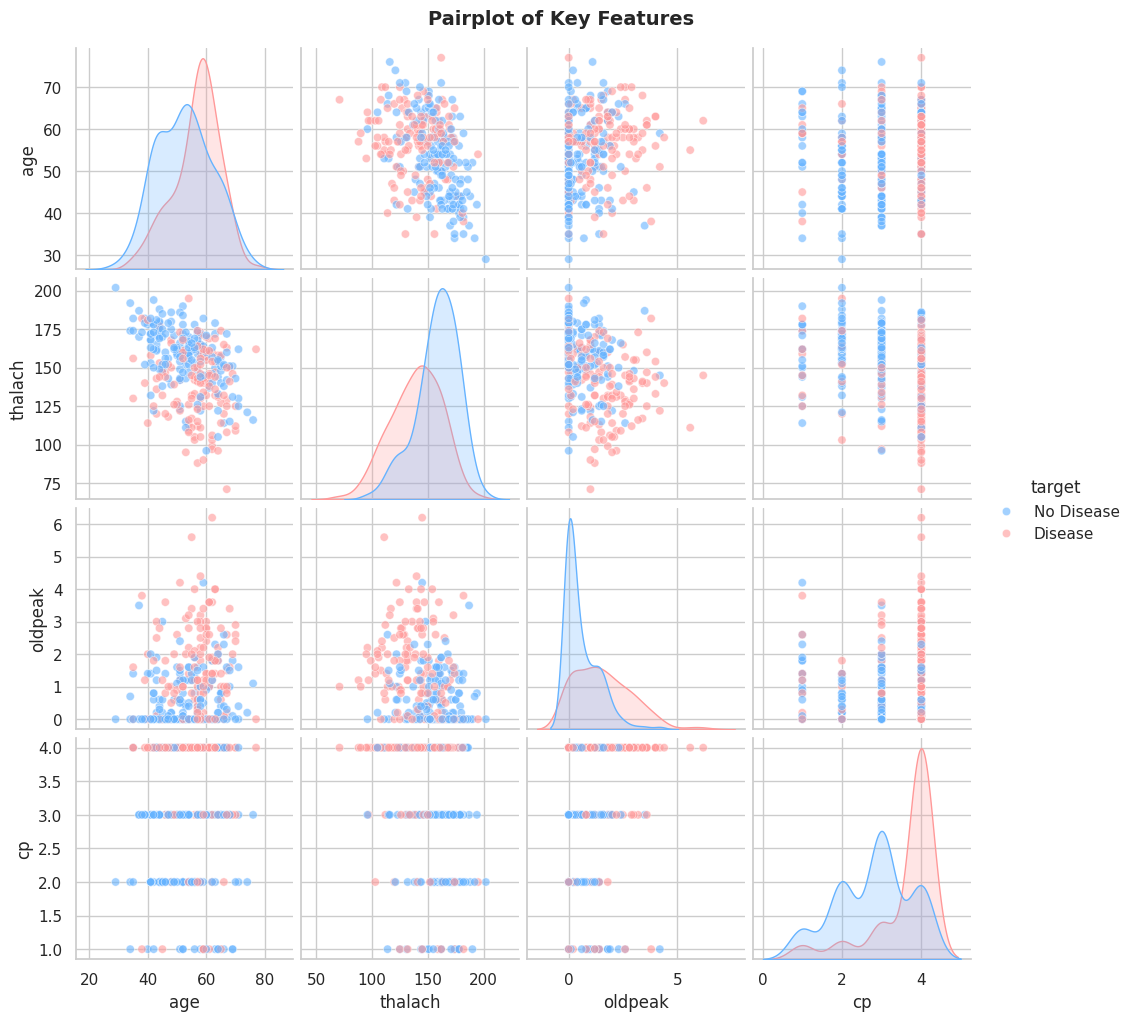

In [11]:
# ── 11. Pairplot (key features) ───────────
pair_df = df[["age", "thalach", "oldpeak", "cp", "target"]].copy()
pair_df["target"] = pair_df["target"].map({0: "No Disease", 1: "Disease"})
pairplot = sns.pairplot(pair_df, hue="target",
                        palette={"No Disease": "#66b3ff", "Disease": "#ff9999"},
                        diag_kind="kde", plot_kws={"alpha": 0.6})
pairplot.fig.suptitle("Pairplot of Key Features", fontsize=14,
                       fontweight="bold", y=1.02)
plt.savefig("extra_pairplot.png", dpi=150)
plt.show()



In [12]:

# ── 12. FEATURE ENGINEERING ──────────────────────────────────
X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✅ Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")




✅ Train: 242 | Test: 61


In [13]:
# ── 13. MODEL TRAINING ───────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("✅ Random Forest model trained.")


✅ Random Forest model trained.


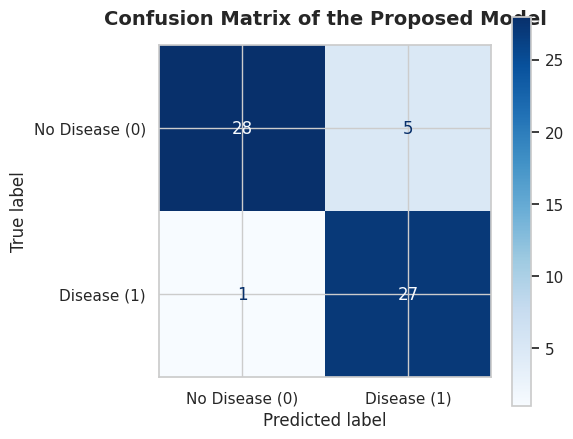

In [14]:
# ── 14. PREDICTIONS & CONFUSION MATRIX ───────────────────────
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No Disease (0)", "Disease (1)"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d", colorbar=True, ax=ax)
ax.set_title("Confusion Matrix of the Proposed Model",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("fig7_confusion_matrix.png", dpi=150)
plt.show()


In [15]:
# ── 15. PERFORMANCE METRICS ──────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred,
      target_names=["No Disease", "Disease"]))

metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
print(pd.DataFrame([metrics]).to_string(index=False))



── Classification Report ──
              precision    recall  f1-score   support

  No Disease       0.97      0.85      0.90        33
     Disease       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61

 Accuracy  Precision   Recall  F1-Score
 0.901639    0.84375 0.964286       0.9


/tmp/ipykernel_602/4190454971.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices],


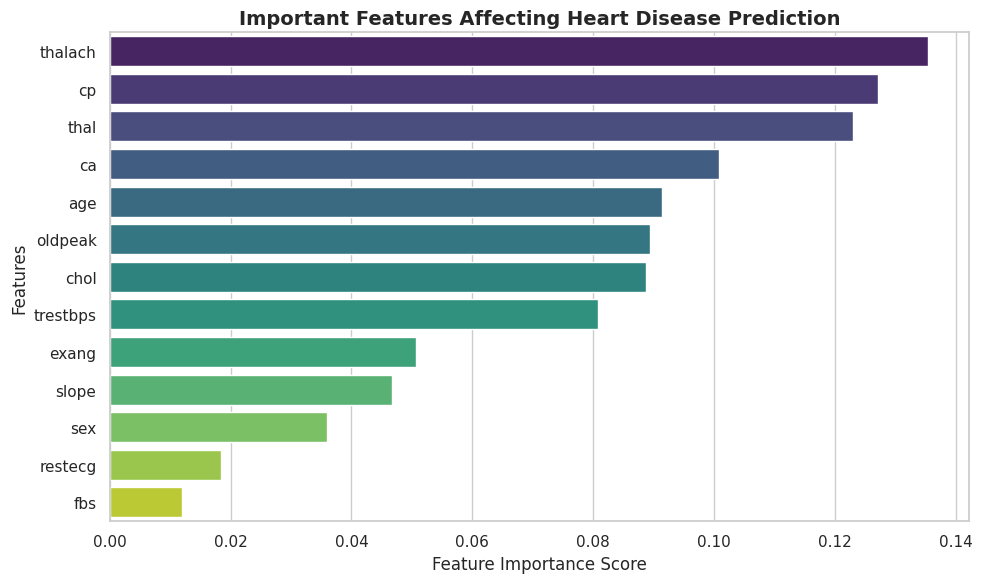

In [16]:
# ── 16. FEATURE IMPORTANCE ───────────────────────────────────
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=importances[indices], y=features[indices],
            palette="viridis", ax=ax)
ax.set_title("Important Features Affecting Heart Disease Prediction",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Feature Importance Score", fontsize=12)
ax.set_ylabel("Features", fontsize=12)
plt.tight_layout()
plt.savefig("fig6_feature_importance.png", dpi=150)
plt.show()



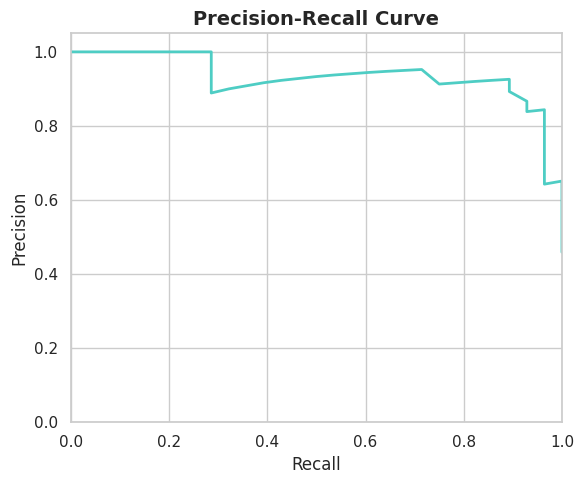

In [18]:
# ── 18. ADDITIONAL PLOT G: Precision-Recall Curve ────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_vals, precision_vals, color="#4ecdc4", lw=2)
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig("extra_precision_recall.png", dpi=150)
plt.show()



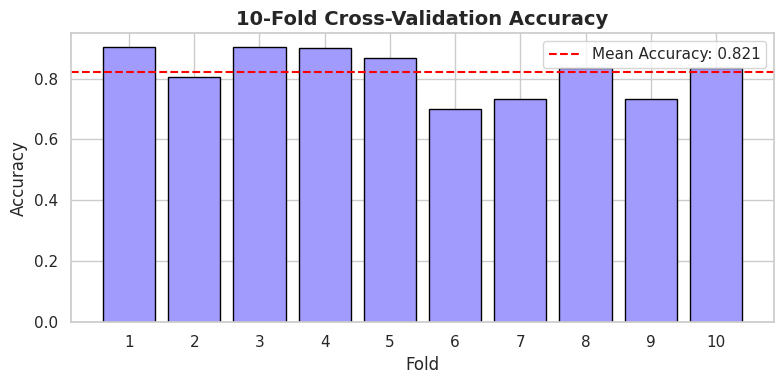


CV Accuracy: 0.8213 ± 0.0724


In [19]:
# ── 19. ADDITIONAL PLOT H: Cross-Validation Scores ───────────
cv_scores = cross_val_score(rf, X_scaled, y, cv=10, scoring="accuracy")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 11), cv_scores, color="#a29bfe", edgecolor="black")
ax.axhline(cv_scores.mean(), color="red", linestyle="--",
           label=f"Mean Accuracy: {cv_scores.mean():.3f}")
ax.set_xlabel("Fold", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("10-Fold Cross-Validation Accuracy", fontsize=14, fontweight="bold")
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.savefig("extra_cross_validation.png", dpi=150)
plt.show()
print(f"\nCV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")



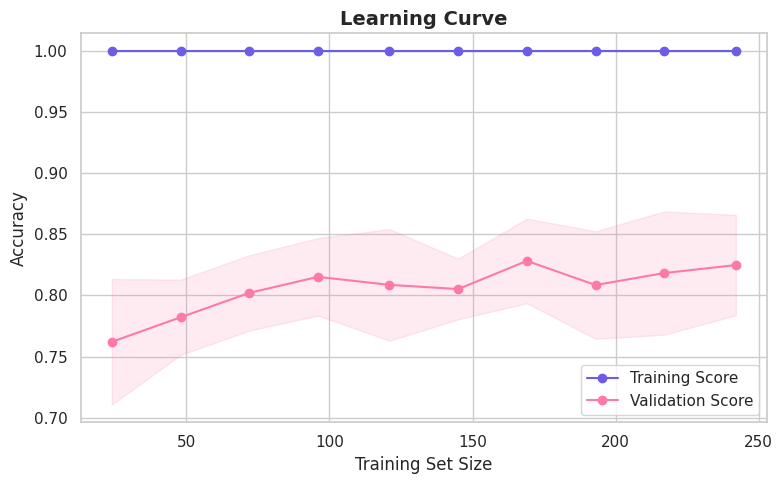

In [20]:
# ── 20. ADDITIONAL PLOT I: Learning Curve ────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    rf, X_scaled, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, "o-", color="#6c5ce7", label="Training Score")
ax.fill_between(train_sizes, train_mean - train_std,
                train_mean + train_std, alpha=0.15, color="#6c5ce7")
ax.plot(train_sizes, val_mean, "o-", color="#fd79a8", label="Validation Score")
ax.fill_between(train_sizes, val_mean - val_std,
                val_mean + val_std, alpha=0.15, color="#fd79a8")
ax.set_title("Learning Curve", fontsize=14, fontweight="bold")
ax.set_xlabel("Training Set Size", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig("extra_learning_curve.png", dpi=150)
plt.show()



In [21]:

# ── 21. SUMMARY ──────────────────────────────────────────────
print("\n" + "="*50)
print("         FINAL PERFORMANCE SUMMARY")
print("="*50)
print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f} ({prec*100:.2f}%)")
print(f"  Recall    : {rec:.4f} ({rec*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f} ({f1*100:.2f}%)")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"  CV Acc    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("="*50)


         FINAL PERFORMANCE SUMMARY
  Accuracy  : 0.9016 (90.16%)
  Precision : 0.8438 (84.38%)
  Recall    : 0.9643 (96.43%)
  F1-Score  : 0.9000 (90.00%)
  ROC-AUC   : 0.9513
  CV Acc    : 0.8213 ± 0.0724
